In [1]:
import os
os.chdir("/home/alexsy/repositories/combinations_predictions")

import joblib
import numpy as np
import pandas as pd
from glob import glob
from sklearn.utils import resample
from imblearn.pipeline import Pipeline
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_score, recall_score
import seaborn as sns 

import matplotlib.pyplot as plt
# Local imports
from src.tuning_ml_models import imcp_score_adapted
from src.cluster_undersampling import ClusterUnderSampler

PATH_TO_PLOTS = 'data/plots'
if not os.path.exists(PATH_TO_PLOTS):
    os.makedirs(PATH_TO_PLOTS)

In [2]:


strain_names = ["Ab17978", "Kp43816", "PAO1", "AbLac4", "Kp0087", "Pa0095"]
dict_paths = {}

split_indices = np.load("data/strains_embs/train_test_splits_indices.npy", allow_pickle=True).item()

for strain in strain_names:
    dict_paths[strain] = {"model":f"data/models/{strain}_lgbm_by_undersampling.pkl",
                          "embs":f"data/strains_embs/{strain}_embeddings.npz",
                          "id_data":f"data/strains_embs/{strain}_data.csv",
                          "train":split_indices[strain]["train"],
                          "test":split_indices[strain]["test"]}

In [3]:
def plot_percentage_confusion_matrix(cm, ax, class_names=None):
    """
    Plots a confusion matrix heatmap colored by row percentages directly onto
    a provided matplotlib Axis object.
    """
    # 1. Calculate percentages (normalize by true labels/rows)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_perc = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)
    
    # 2. Build custom annotation labels combining count and percentage
    blanks = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            cnt = cm[i, j]
            pct = cm_perc[i, j] * 100
            blanks[i, j] = f"{cnt}\n({pct:.1f}%)"
            
    # 3. Plot onto the passed axis (ax=ax)
    sns.heatmap(
        cm_perc, 
        annot=blanks, 
        fmt="",            
        cmap="Blues", 
        vmin=0, vmax=1,    
        xticklabels=class_names if class_names else True,
        yticklabels=class_names if class_names else True,
        ax=ax,             # <--- This directs seaborn to the specific subplot
        cbar=True          # Set to False if you don't want a colorbar for every subplot
    )
    
    # Use ax.set_* methods instead of plt.set_* for subplots
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    
    return ax

/home/alexsy/miniconda3/envs/py_ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Ab17978
Precision:0.27
Recall:0.47


/home/alexsy/miniconda3/envs/py_ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Kp43816
Precision:0.22
Recall:0.33


/home/alexsy/miniconda3/envs/py_ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

AbLac4
Precision:0.27
Recall:0.50


/home/alexsy/miniconda3/envs/py_ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Kp0087
Precision:0.30
Recall:0.52


/home/alexsy/miniconda3/envs/py_ml/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Pa0095
Precision:0.27
Recall:0.54


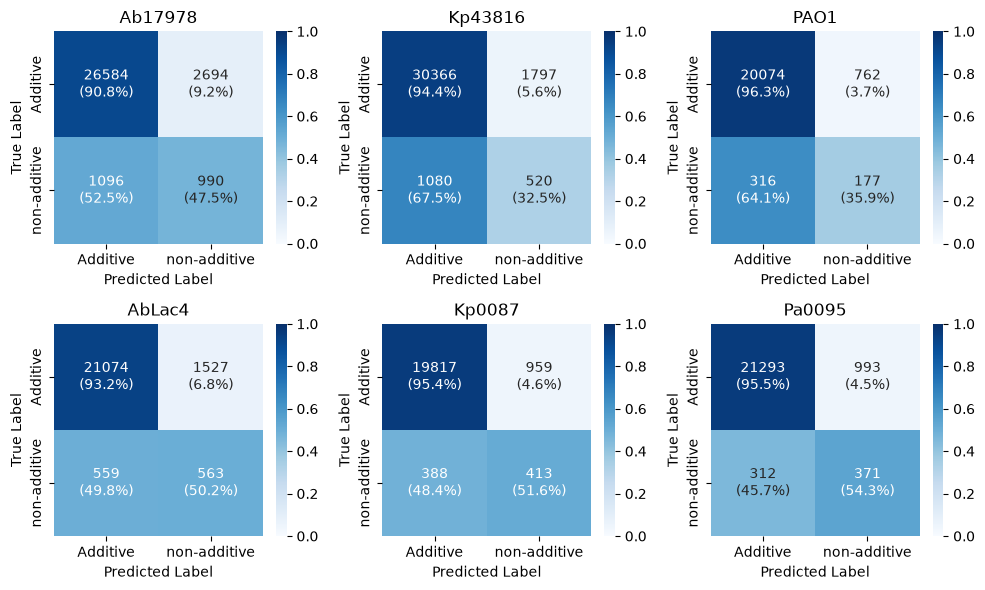

In [4]:
fig, axes = plt.subplots(2,3, figsize=(10, 6))

axes = axes.flatten()  # Flatten the 2D array of axes to 1D for easier iteration
for i, strain in enumerate(strain_names):

    train_indices = dict_paths[strain]["train"]
    test_indices = dict_paths[strain]["test"]

    model = joblib.load(dict_paths[strain]["model"]).best_estimator_
    emb_data = np.load(dict_paths[strain]["embs"])['arr_0']
    id_data = pd.read_csv(dict_paths[strain]["id_data"])

    X_test = emb_data[test_indices][:,:-1]
    y_test = emb_data[test_indices][:,-1]

    threshold = 0.8  # Set your desired threshold here
    y_predict_proba = model.predict_proba(X_test)[:, 1]
    y_pred = (y_predict_proba >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    print(f"{strain}\nPrecision:{precision:.2f}\nRecall:{recall:.2f}")

    cm = confusion_matrix(y_test, y_pred)
    

    plot_percentage_confusion_matrix(cm, axes[i], class_names=["Additive", "non-additive"])
    axes[i].set_title(f"{strain}")

plt.tight_layout()
plt.savefig(f"{PATH_TO_PLOTS}/confusion_matrices.svg", dpi=300)

    